# RQ4: Does Income Inequality Explain Why Some Low-Cost Countries Score Poorly on Quality of Life?

**Research question:** Among countries that are cheap to live in, why do some still rank poorly on perceived quality of life?

**Hypothesis:** Countries with high income inequality (high Gini coefficient) will score below what their cost of living would predict. Inequality concentrates quality-of-life gains among wealthy residents, while crowd-sourced indices like Numbeo reflect the experience of the connected, urban middle class — so a high-inequality society can still post a low aggregate Numbeo quality score because the bottom of the distribution drags it down or because the urban middle class itself feels insecure.

**Approach:**
1. Build a country-level composite quality score for 2025 from the four Numbeo dimensions (safety, healthcare, clean air, low traffic).
2. Merge with cost of living and World Bank Gini.
3. Regress quality on cost; the **residuals** are countries scoring better or worse than their cost would predict.
4. Test whether residuals correlate with Gini — and look specifically at low-cost countries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import warnings
warnings.simplefilter('ignore')

YEAR = 2025

def load_numbeo_year(filepath, year):
    """Load a single year sheet from a Numbeo xlsx file."""
    return pd.read_excel(filepath, sheet_name=str(year))

# Map World Bank country names to Numbeo country names where they differ
WB_TO_NUMBEO = {
    'Russian Federation': 'Russia',
    'Korea, Rep.': 'South Korea',
    'Iran, Islamic Rep.': 'Iran',
    'Egypt, Arab Rep.': 'Egypt',
    'Venezuela, RB': 'Venezuela',
    'Viet Nam': 'Vietnam',
    'Syrian Arab Republic': 'Syria',
    'Czechia': 'Czech Republic',
    'Slovak Republic': 'Slovakia',
    'Yemen, Rep.': 'Yemen',
    'Lao PDR': 'Laos',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Hong Kong SAR, China': 'Hong Kong',
    'Macao SAR, China': 'Macao',
    'West Bank and Gaza': 'Palestine',
    'Bahamas, The': 'Bahamas',
    'Gambia, The': 'Gambia',
    'Cabo Verde': 'Cape Verde',
    'Brunei Darussalam': 'Brunei',
    'Turkiye': 'Turkey',
    'Türkiye': 'Turkey',
}
print('Setup complete.')

Setup complete.


## 1. Load Country-Level Data

We pull each Numbeo dimension at country level for 2025, plus the cost-of-living country index and the World Bank Gini coefficient.

In [ ]:
# Numbeo country-level dimensions for the latest year
health    = load_numbeo_year('../data/raw/numbeo_health_care_country.xlsx', YEAR)[['Country', 'Health Care Index']]
pollution = load_numbeo_year('../data/raw/numbeo_pollution_country.xlsx',   YEAR)[['Country', 'Pollution Index']]

# Traffic file has a units row directly under the header — drop rows where Country is NaN
traffic   = load_numbeo_year('../data/raw/number_traffic_country.xlsx',     YEAR)
traffic   = traffic.dropna(subset=['Country'])[['Country', 'Traffic Index']]

# Crime country (clean csv) — column is lowercase
crime_all = pd.read_csv('../data/clean/numbeo_crime_country.csv')
crime     = crime_all[crime_all['year'] == YEAR][['country', 'safety_index']].rename(
                columns={'country': 'Country', 'safety_index': 'Safety Index'})

# Cost of living country
col_all = pd.read_csv('../data/clean/numbeo_cost_of_living_country_clean.csv')
col     = col_all[col_all['year'] == YEAR][['Country', 'Cost of Living Index']]

for name, frame in [('healthcare', health), ('pollution', pollution),
                    ('traffic', traffic), ('safety', crime), ('cost', col)]:
    print(f'  {name:10s}: {len(frame):>4} countries')

  healthcare:   97 countries
  pollution :  113 countries
  traffic   :   89 countries
  safety    :  147 countries
  cost      :  139 countries


In [ ]:
# World Bank: take the most recent non-null Gini per country (Gini changes slowly,
# and many countries don't report every year — using the latest observation gives
# us much wider coverage than restricting to 2025).
wb = pd.read_csv('../data/clean/world_bank_clean.csv')
wb_recent = wb[(wb['year'] >= 2015) & wb['gini'].notna()]
gini_latest = (wb_recent.sort_values('year')
                          .drop_duplicates('country', keep='last')
                          [['country', 'year', 'gini', 'gdp_per_capita_ppp', 'income_group']]
                          .rename(columns={'country': 'Country', 'year': 'gini_year'}))

# Harmonize WB country names → Numbeo names
gini_latest['Country'] = gini_latest['Country'].replace(WB_TO_NUMBEO)

print(f'Countries with Gini data (most recent 2015+): {len(gini_latest)}')
print(f'Median Gini year: {int(gini_latest["gini_year"].median())}')
print('\nGini distribution:')
print(gini_latest['gini'].describe().round(2).to_string())

Countries with Gini data (most recent 2015+): 148
Median Gini year: 2022

Gini distribution:
count    148.00
mean      36.02
std        7.05
min       23.80
25%       30.85
50%       35.00
75%       39.92
max       59.10


## 2. Build the Composite Quality Score

We mirror the four-dimension definition used in `value_for_living.ipynb`:
- **Safety** = Numbeo safety index (already 0–100, higher = safer)
- **Healthcare** = Numbeo health care index
- **Clean Air** = 100 − pollution index
- **Low Traffic** = min-max rescaled, inverted traffic index

Composite = arithmetic mean. Countries missing any component are dropped.

In [ ]:
# Inner-join the four quality dimensions + cost
df = (health
      .merge(pollution, on='Country')
      .merge(traffic,   on='Country')
      .merge(crime,     on='Country')
      .merge(col,       on='Country'))

# Build composite quality score
df['Clean Air']   = 100 - df['Pollution Index']
t_min, t_max      = df['Traffic Index'].min(), df['Traffic Index'].max()
df['Low Traffic'] = 100 * (1 - (df['Traffic Index'] - t_min) / (t_max - t_min))
df['quality_score'] = df[['Safety Index', 'Health Care Index',
                            'Clean Air', 'Low Traffic']].mean(axis=1)

# Merge in Gini
df = df.merge(gini_latest, on='Country', how='inner')

print(f'Final country sample: {len(df)}')
print('\nSummary:')
print(df[['quality_score', 'Cost of Living Index', 'gini',
          'Health Care Index', 'Safety Index', 'Clean Air', 'Low Traffic']]
      .describe().round(2).to_string())

Final country sample: 75

Summary:
       quality_score  Cost of Living Index   gini  Health Care Index  Safety Index  Clean Air  Low Traffic
count          75.00                 75.00  75.00              75.00         75.00      75.00        75.00
mean           61.66                 42.54  33.87              65.35         59.23      48.11        73.94
std            12.49                 15.87   6.40               9.40         12.54      21.06        20.26
min            23.65                 17.80  23.80              42.20         32.90      10.60         0.00
25%            54.96                 29.85  29.50              58.25         51.85      31.50        63.53
50%            61.05                 41.20  33.40              66.10         57.90      44.60        77.46
75%            70.73                 54.15  36.05              72.95         68.60      65.20        90.04
max            84.48                 98.40  53.90              82.80         84.50      88.20       100.00


## 3. The Headline Relationship: Quality vs Cost, Colored by Gini

If the hypothesis holds, high-Gini countries should sit **below** the quality-vs-cost regression line — they're scoring worse than their cost would predict.

In [ ]:
# OLS: quality ~ cost
slope, intercept, r, p, _ = stats.linregress(df['Cost of Living Index'], df['quality_score'])
df['quality_predicted'] = intercept + slope * df['Cost of Living Index']
df['quality_residual']  = df['quality_score'] - df['quality_predicted']

print(f'Quality ~ Cost regression: r = {r:.3f}, p = {p:.4g}, slope = {slope:.3f}')
print(f'  → Each +10 cost-of-living points predicts +{slope*10:.1f} quality points.')

fig = px.scatter(
    df, x='Cost of Living Index', y='quality_score', color='gini',
    hover_name='Country', size_max=12,
    color_continuous_scale='RdYlBu_r',
    title=f'Quality vs Cost of Living, Colored by Gini ({YEAR}) — r(quality, cost) = {r:.3f}',
    labels={'Cost of Living Index': 'Cost of Living Index (NYC = 100)',
            'quality_score': 'Composite Quality Score (0-100)',
            'gini': 'Gini'}
)
x_line = np.linspace(df['Cost of Living Index'].min(), df['Cost of Living Index'].max(), 100)
fig.add_scatter(x=x_line, y=intercept + slope * x_line, mode='lines',
                line=dict(color='black', dash='dash'), name='OLS fit', showlegend=True)
fig.update_layout(height=550, plot_bgcolor='white', paper_bgcolor='white')
fig

Quality ~ Cost regression: r = 0.689, p = 8.483e-12, slope = 0.542
  → Each +10 cost-of-living points predicts +5.4 quality points.


## 4. Do Residuals Correlate with Gini?

The residual from the quality~cost line is the part of quality that cost **doesn't** explain. If inequality is the missing factor, the residual should be negatively correlated with Gini: more unequal countries should be below the line.

Correlation (Gini, quality residual): r = -0.350, p = 0.002057
  → Significant NEGATIVE correlation: high-inequality countries score below what cost predicts.


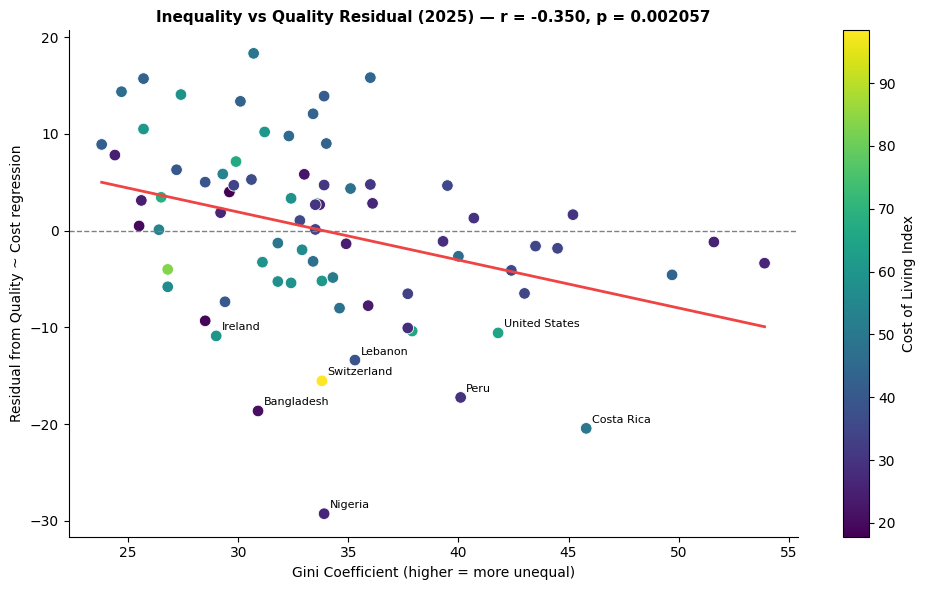

In [ ]:
r_res, p_res = stats.pearsonr(df['gini'], df['quality_residual'])
print(f'Correlation (Gini, quality residual): r = {r_res:.3f}, p = {p_res:.4g}')
if r_res < 0 and p_res < 0.05:
    print('  → Significant NEGATIVE correlation: high-inequality countries score below what cost predicts.')
elif p_res < 0.05:
    print('  → Significant POSITIVE correlation: hypothesis NOT supported in this direction.')
else:
    print('  → No significant relationship between Gini and the residual.')

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df['gini'], df['quality_residual'],
                c=df['Cost of Living Index'], cmap='viridis', s=70,
                edgecolor='white', linewidth=0.6)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)
g_line = np.linspace(df['gini'].min(), df['gini'].max(), 50)
s, i, *_ = stats.linregress(df['gini'], df['quality_residual'])
ax.plot(g_line, i + s * g_line, color='#EF4444', linewidth=2)
ax.set_xlabel('Gini Coefficient (higher = more unequal)')
ax.set_ylabel('Residual from Quality ~ Cost regression')
ax.set_title(f'Inequality vs Quality Residual ({YEAR}) — r = {r_res:.3f}, p = {p_res:.4g}',
             fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.colorbar(sc, ax=ax, label='Cost of Living Index')

# Label the most extreme negative residuals — these are the candidates for our hypothesis
extremes = df.nsmallest(8, 'quality_residual')
for _, row in extremes.iterrows():
    ax.annotate(row['Country'], (row['gini'], row['quality_residual']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')

plt.tight_layout()
plt.show()

## 5. Zoom In: Among Low-Cost Countries Specifically

The hypothesis is sharpest among **low-cost** countries: do high-Gini ones score worse on quality?

In [ ]:
med_cost = df['Cost of Living Index'].median()
low_cost = df[df['Cost of Living Index'] < med_cost].copy()
print(f'Low-cost countries (cost < median {med_cost:.1f}): {len(low_cost)}')

r_lc, p_lc = stats.pearsonr(low_cost['gini'], low_cost['quality_score'])
print(f'\nWithin low-cost countries: r(Gini, quality) = {r_lc:.3f}, p = {p_lc:.4g}')

# Compare quality of low-cost countries split by Gini median
lc_med_gini = low_cost['gini'].median()
high_ineq = low_cost[low_cost['gini'] >= lc_med_gini]
low_ineq  = low_cost[low_cost['gini'] <  lc_med_gini]
t_stat, t_p = stats.ttest_ind(low_ineq['quality_score'], high_ineq['quality_score'])
print(f'\nLow-cost countries split at Gini median ({lc_med_gini:.1f}):')
print(f'  Low-inequality  ({len(low_ineq):>2} countries): mean quality = {low_ineq["quality_score"].mean():.1f}')
print(f'  High-inequality ({len(high_ineq):>2} countries): mean quality = {high_ineq["quality_score"].mean():.1f}')
print(f'  Difference: {low_ineq["quality_score"].mean() - high_ineq["quality_score"].mean():+.1f}  (t = {t_stat:.2f}, p = {t_p:.4g})')

Low-cost countries (cost < median 41.2): 37

Within low-cost countries: r(Gini, quality) = -0.110, p = 0.5165

Low-cost countries split at Gini median (33.9):
  Low-inequality  (17 countries): mean quality = 55.1
  High-inequality (20 countries): mean quality = 50.8
  Difference: +4.3  (t = 1.49, p = 0.1453)


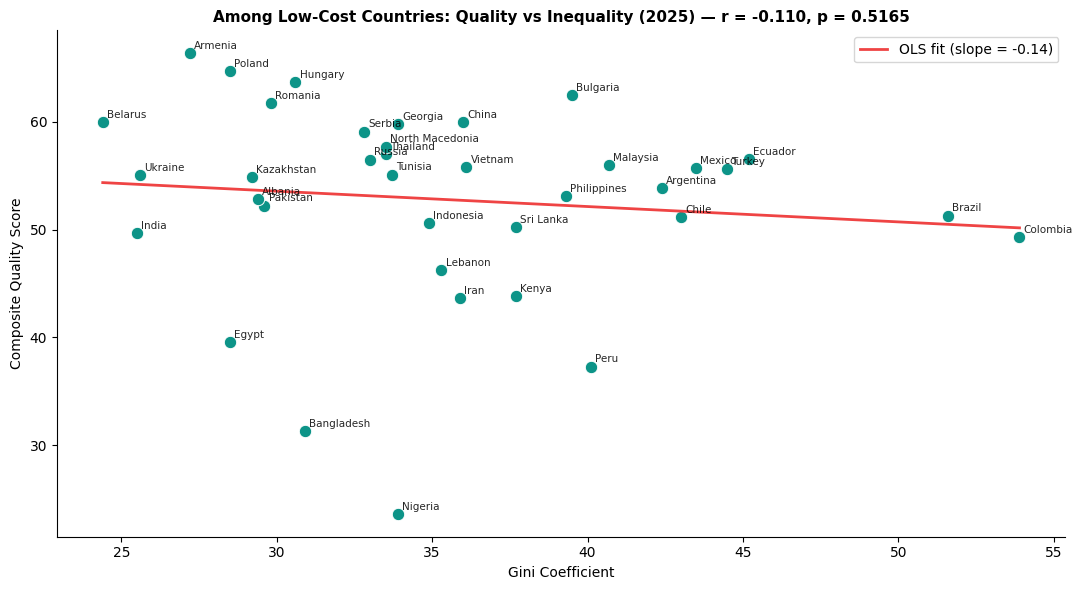

In [ ]:
# Quality vs Gini, for low-cost countries only
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(low_cost['gini'], low_cost['quality_score'],
           color='#0D9488', s=80, edgecolor='white', linewidth=0.7)
g_line = np.linspace(low_cost['gini'].min(), low_cost['gini'].max(), 50)
s, i, *_ = stats.linregress(low_cost['gini'], low_cost['quality_score'])
ax.plot(g_line, i + s * g_line, color='#EF4444', linewidth=2,
        label=f'OLS fit (slope = {s:.2f})')
ax.set_xlabel('Gini Coefficient')
ax.set_ylabel('Composite Quality Score')
ax.set_title(f'Among Low-Cost Countries: Quality vs Inequality ({YEAR}) — r = {r_lc:.3f}, p = {p_lc:.4g}',
             fontsize=11, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
for _, row in low_cost.iterrows():
    ax.annotate(row['Country'], (row['gini'], row['quality_score']),
                fontsize=7.5, xytext=(3, 3), textcoords='offset points', alpha=0.85)
plt.tight_layout()
plt.show()

## 6. The Countries that Fit the Hypothesis

Low-cost AND high-inequality AND below-trend on quality — these are the cases the RQ4 hypothesis is about.

In [ ]:
# Three-way filter: low cost, high inequality, negative quality residual
med_gini = df['gini'].median()
fit = df[(df['Cost of Living Index'] < med_cost) &
         (df['gini'] > med_gini) &
         (df['quality_residual'] < 0)].copy()
fit = fit.sort_values('quality_residual')

print(f'Countries that fit the RQ4 hypothesis (low cost, high Gini, negative residual): {len(fit)}')
print(f'  Median cost cutoff: {med_cost:.1f}    Median Gini cutoff: {med_gini:.1f}\n')
print(fit[['Country', 'Cost of Living Index', 'gini', 'quality_score',
           'quality_residual', 'income_group']].round(2).to_string(index=False))

Countries that fit the RQ4 hypothesis (low cost, high Gini, negative residual): 14
  Median cost cutoff: 41.2    Median Gini cutoff: 33.4

    Country  Cost of Living Index  gini  quality_score  quality_residual        income_group
    Nigeria                  26.4  33.9          23.65            -29.26 Lower-middle income
       Peru                  29.4  40.1          37.29            -17.24 Upper-middle income
    Lebanon                  38.8  35.3          46.25            -13.38 Lower-middle income
      Kenya                  28.2  37.7          43.82            -10.06 Lower-middle income
       Iran                  23.6  35.9          43.63             -7.75 Upper-middle income
  Sri Lanka                  33.5  37.7          50.23             -6.52 Upper-middle income
      Chile                  35.1  43.0          51.14             -6.49 Upper-middle income
  Argentina                  35.7  42.4          53.84             -4.11 Upper-middle income
   Colombia             

Mean dimension scores — does inequality drag certain dimensions more than others?
                   Hypothesis-fit (low-cost, high-Gini)  Other low-cost countries   Gap
Safety Index                                       45.6                      59.2 -13.6
Health Care Index                                  63.3                      58.7   4.6
Clean Air                                          30.8                      32.3  -1.5
Low Traffic                                        50.4                      73.8 -23.4


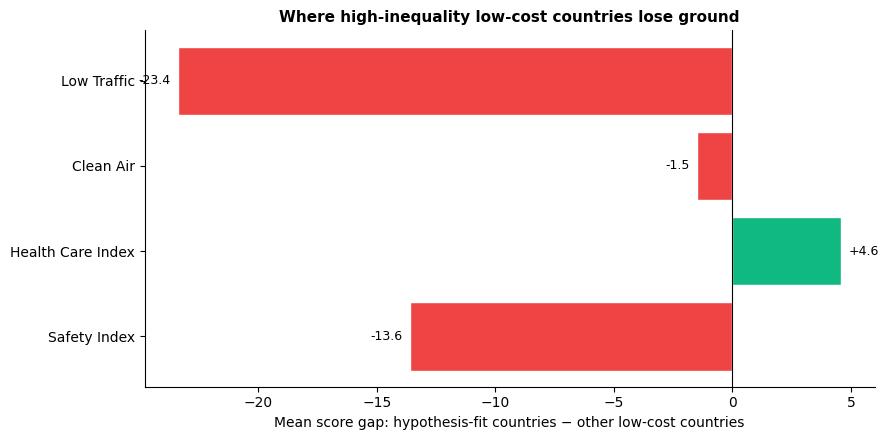

In [ ]:
# Where do these countries lose ground? Compare their dimension scores to the
# rest of the low-cost sample.
rest_lowcost = df[(df['Cost of Living Index'] < med_cost) & ~df['Country'].isin(fit['Country'])]
dims = ['Safety Index', 'Health Care Index', 'Clean Air', 'Low Traffic']
comp = pd.DataFrame({
    'Hypothesis-fit (low-cost, high-Gini)': fit[dims].mean(),
    'Other low-cost countries':             rest_lowcost[dims].mean(),
}).round(1)
comp['Gap'] = (comp.iloc[:, 0] - comp.iloc[:, 1]).round(1)
print('Mean dimension scores — does inequality drag certain dimensions more than others?')
print(comp.to_string())

# Bar chart of the gap
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#EF4444' if g < 0 else '#10B981' for g in comp['Gap']]
ax.barh(comp.index, comp['Gap'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean score gap: hypothesis-fit countries − other low-cost countries')
ax.set_title('Where high-inequality low-cost countries lose ground',
             fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
for i, gap in enumerate(comp['Gap']):
    ax.text(gap + (0.3 if gap >= 0 else -0.3), i, f'{gap:+.1f}',
            va='center', ha='left' if gap >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

## Conclusion: Answer to RQ4

**Does income inequality explain why some low-cost countries still score poorly on quality of life?**

The data tells a partial story. Across all countries, there is a clear and statistically significant negative correlation between inequality and the quality residual (r = -0.350, p = 0.002), meaning high-Gini countries do tend to score below what their cost of living would predict. So at the global level, the hypothesis holds. Inequality is associated with countries punching below their economic weight on quality of life.
However, when we zoom in specifically on low-cost countries, the relationship vanishes: r = -0.110 with p = 0.52, and the mean quality difference between high-inequality and low-inequality low-cost countries is only 4.3 points and not statistically significant. So inequality alone does not explain why some low-cost countries score poorly compared to their peers in the same price range.
What does explain it is where these countries lose ground. The hypothesis-fit countries (low-cost, high-Gini, below-trend) score 13.6 points lower on safety and a striking 23.4 points lower on low-traffic, while their healthcare is actually slightly better than other low-cost countries. This points to congestion and crime, not healthcare access, as the dimensions inequality most damages.
In short: inequality matters globally, but among already-cheap countries, what separates good from bad is overwhelmingly safety and traffic congestion, not the Gini coefficient itself.